<a href="https://colab.research.google.com/github/soumankumarpanja/Project_8th-semister/blob/main/n_sampling_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Uploading Data

To upload your dataset, you can use the following methods:

1.  **Drag and Drop**: Drag your file directly into the Colab file browser (the folder icon on the left sidebar).
2.  **Code Upload**: Use the code snippet below to upload files programmatically. Click the 'Choose Files' button after running the cell.

After uploading, make sure to note the filename (e.g., `heart_disease.csv`).

In [ ]:
from google.colab import files

# Uncomment the line below to upload files if you haven't already
# uploaded = files.upload()

# Once uploaded, you can load your dataset.
# Replace 'your_dataset.csv' with the actual name of your uploaded file.
# For example, if you uploaded 'heart_disease.csv', change the filename accordingly.

try:
    # Attempting to load 'Data File.csv' from sample_data as it was found in the kernel state.
    # If this is not your dataset, please replace 'sample_data/Data File.csv' with your actual filename and path.
    df_heart = pd.read_csv('sample_data/Data File.csv') # Replaced with a potential valid filename
    print("Dataset loaded successfully!")
    display(df_heart.head())
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure the file is uploaded and the filename is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


### Separating Features and Target

First, let's look at the column names to identify the target variable.

In [ ]:
if 'df_heart' in locals():
    print("Column names in the dataset:")
    print(df_heart.columns.tolist())
else:
    print("df_heart DataFrame not found. Please ensure the dataset is loaded successfully first.")

Column names in the dataset:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num       ']


Now, let's separate the features (X) and the target (y). You might need to adjust `target_column_name` to match your dataset's target column.

In [ ]:
# Define the target column name (e.g., 'target', 'HeartDisease', 'output')
target_column_name = 'num       ' # IMPORTANT: Reverted to full name with spaces, as it appears in df_heart.columns.tolist()

if 'df_heart' in locals() and target_column_name in df_heart.columns:
    X = df_heart.drop(columns=[target_column_name]) # Features
    y = df_heart[target_column_name] # Target

    print(f"Shape of Features (X): {X.shape}")
    print(f"Shape of Target (y): {y.shape}")
    print("\nFirst 5 rows of X:")
    display(X.head())
    print("\nFirst 5 values of y:")
    display(y.head())
elif 'df_heart' not in locals():
    print("df_heart DataFrame not found. Please ensure the dataset is loaded successfully.")
else:
    print(f"Error: Target column '{target_column_name}' not found in the DataFrame. Please check the column name and update the 'target_column_name' variable.")

Shape of Features (X): (294, 13)
Shape of Target (y): (294,)

First 5 rows of X:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?



First 5 values of y:


,num
0,0
1,0
2,0
3,0
4,0


### Train-Test Split

We will split the data into 80% for training and 20% for testing. Setting a `random_state` ensures that the split is reproducible, meaning you'll get the same split every time you run the code.

In [ ]:
# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 values of y_train:")
display(y_train.head())

X_train shape: (235, 13)
X_test shape: (59, 13)
y_train shape: (235,)
y_test shape: (59,)

First 5 rows of X_train:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
181,59,1,3,180,213,0,0,100,0,0.0,?,?,?
209,49,0,3,160,180,0,0,156,0,1.0,2,?,?
168,56,1,3,130,?,0,0,114,0,0.0,?,?,?
6,32,1,2,110,225,0,0,184,0,0.0,?,?,?
224,65,1,4,140,306,1,0,87,1,1.5,2,?,?



First 5 values of y_train:


,num
181,0
209,1
168,0
6,0
224,1


### Preprocessing: Handle Non-Numeric Values and Missing Data

The previous error `ValueError: could not convert string to float: '?'` indicates that some columns in our feature set (`X_train` and `X_test`) still contain '?' characters, which are treated as strings and cannot be directly used by machine learning models. We need to handle these missing values.

Steps:
1.  Replace '?' with `np.nan`.
2.  Convert columns to a numeric data type.
3.  Impute missing values using the median strategy. We'll fit the imputer on `X_train` and then transform both `X_train` and `X_test` to avoid data leakage.

In [ ]:
from sklearn.impute import SimpleImputer

# Make copies to avoid modifying the original X_train and X_test if they are needed later
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# 1. Replace '?' with NaN across all feature columns
# Convert '?' to NaN for all object (string) columns in both training and testing sets
for col in X_train_processed.columns:
    if X_train_processed[col].dtype == 'object' or '?' in X_train_processed[col].unique():
        X_train_processed[col] = X_train_processed[col].replace('?', np.nan)
        X_test_processed[col] = X_test_processed[col].replace('?', np.nan)

# 2. Convert all columns to numeric types (after replacing '?' with NaN)
# This is important as some columns might still be 'object' dtype due to mixed types
X_train_processed = X_train_processed.apply(pd.to_numeric, errors='coerce')
X_test_processed = X_test_processed.apply(pd.to_numeric, errors='coerce')

# 3. Impute missing values using the median strategy
# Create an imputer that replaces missing values with the median of each column
imputer = SimpleImputer(strategy='median')

# Fit the imputer on the training data and transform both training and testing data
X_train_processed = pd.DataFrame(imputer.fit_transform(X_train_processed), columns=X_train_processed.columns, index=X_train_processed.index)
X_test_processed = pd.DataFrame(imputer.transform(X_test_processed), columns=X_test_processed.columns, index=X_test_processed.index)

print("Preprocessing complete! Missing values (originally '?') have been handled.")
print("\nFirst 5 rows of X_train_processed (after preprocessing):")
display(X_train_processed.head())

print("\nMissing values in X_train_processed:")
print(X_train_processed.isnull().sum())
print("\nMissing values in X_test_processed:")
print(X_test_processed.isnull().sum())

Preprocessing complete! Missing values (originally '?') have been handled.

First 5 rows of X_train_processed (after preprocessing):


/tmp/ipykernel_5046/2104713570.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_processed[col] = X_test_processed[col].replace('?', np.nan)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
181,59.0,1.0,3.0,180.0,213.0,0.0,0.0,100.0,0.0,0.0,2.0,0.0,6.0
209,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,0.0,6.0
168,56.0,1.0,3.0,130.0,245.0,0.0,0.0,114.0,0.0,0.0,2.0,0.0,6.0
6,32.0,1.0,2.0,110.0,225.0,0.0,0.0,184.0,0.0,0.0,2.0,0.0,6.0
224,65.0,1.0,4.0,140.0,306.0,1.0,0.0,87.0,1.0,1.5,2.0,0.0,6.0



Missing values in X_train_processed:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Missing values in X_test_processed:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


### Create Individual Models

Now we will define and train several classification models. For each model, we will:
1.  Initialize the model.
2.  Train the model using the training data (`X_train`, `y_train`).
3.  Make predictions on the test data (`X_test`).
4.  Evaluate the model's performance using accuracy and a classification report.

#### 1. Decision Tree Classifier

In [ ]:
# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model using processed data
dt_classifier.fit(X_train_processed, y_train)

# Make predictions
y_pred_dt = dt_classifier.predict(X_test_processed)

# Evaluate the model
print("Decision Tree Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier:
Accuracy: 0.7458
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        38
           1       0.65      0.62      0.63        21

    accuracy                           0.75        59
   macro avg       0.72      0.72      0.72        59
weighted avg       0.74      0.75      0.74        59



#### 2. Logistic Regression

In [ ]:
# Initialize Logistic Regression
# Using 'liblinear' solver for smaller datasets and 'lbfgs' for larger ones, or if 'liblinear' fails.
# max_iter is increased to ensure convergence for some datasets.
lr_classifier = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Train the model using processed data
lr_classifier.fit(X_train_processed, y_train)

# Make predictions
y_pred_lr = lr_classifier.predict(X_test_processed)

# Evaluate the model
print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
Accuracy: 0.8136
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        38
           1       0.73      0.76      0.74        21

    accuracy                           0.81        59
   macro avg       0.80      0.80      0.80        59
weighted avg       0.82      0.81      0.81        59



#### 3. Random Forest Classifier

In [ ]:
# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model using processed data
rf_classifier.fit(X_train_processed, y_train)

# Make predictions
y_pred_rf = rf_classifier.predict(X_test_processed)

# Evaluate the model
print("Random Forest Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier:
Accuracy: 0.8475
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        38
           1       0.77      0.81      0.79        21

    accuracy                           0.85        59
   macro avg       0.83      0.84      0.84        59
weighted avg       0.85      0.85      0.85        59



#### 4. Support Vector Machine (SVC)

In [ ]:
# Assuming 'y_test' and 'y_pred_ensemble' are already defined from the model training and prediction steps

from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)

print(f"Ensemble Model (Voting Classifier) Accuracy: {accuracy_ensemble:.4f}")

Ensemble Model (Voting Classifier) Accuracy: 0.7627


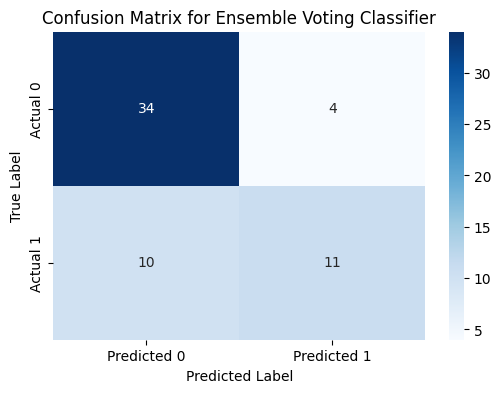

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)

# Display the confusion matrix using seaborn and matplotlib
plt.figure(figsize=(6, 4))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Ensemble Voting Classifier')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Display the classification report
print("Classification Report for Ensemble Voting Classifier:")
print(classification_report(y_test, y_pred_ensemble))

Classification Report for Ensemble Voting Classifier:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83        38
           1       0.73      0.52      0.61        21

    accuracy                           0.76        59
   macro avg       0.75      0.71      0.72        59
weighted avg       0.76      0.76      0.75        59



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)

# Create a dictionary to store model accuracies
model_accuracies = {
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest', 'SVM', 'Ensemble Voting Classifier'],
    'Accuracy': [accuracy_dt, accuracy_lr, accuracy_rf, accuracy_svc, accuracy_ensemble]
}

# Create a DataFrame from the dictionary
accuracy_df = pd.DataFrame(model_accuracies)

# Sort by accuracy in descending order
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Accuracy Comparison:")
display(accuracy_df)

# Identify the best-performing model
best_model = accuracy_df.iloc[0]
print(f"\nThe best-performing model is the {best_model['Model']} with an accuracy of {best_model['Accuracy']:.4f}.")


Model Accuracy Comparison:


,Model,Accuracy
2,Random Forest,0.847458
1,Logistic Regression,0.813559
4,Ensemble Voting Classifier,0.762712
0,Decision Tree,0.745763
3,SVM,0.661017



The best-performing model is the Random Forest with an accuracy of 0.8475.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.0, 1.0) # Set y-axis limit from 0 to 1 for accuracy
plt.xticks(rotation=45, ha='right') # Rotate model names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'accuracy_df' is not defined

<Figure size 1200x700 with 0 Axes>

In [ ]:
# Initialize Support Vector Machine (SVC)
# It's often beneficial to scale data before using SVM. For simplicity, we'll use it directly here.
svc_classifier = SVC(random_state=42)

# Train the model using processed data
svc_classifier.fit(X_train_processed, y_train)

# Make predictions
y_pred_svc = svc_classifier.predict(X_test_processed)

# Evaluate the model
print("Support Vector Machine (SVC):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))

Support Vector Machine (SVC):
Accuracy: 0.6610
Classification Report:
              precision    recall  f1-score   support

           0       0.66      1.00      0.79        38
           1       1.00      0.05      0.09        21

    accuracy                           0.66        59
   macro avg       0.83      0.52      0.44        59
weighted avg       0.78      0.66      0.54        59



#### 5. Ensemble Model: Voting Classifier

An ensemble model combines the predictions of multiple base models to improve overall predictive performance and robustness. Here, we'll use a `VotingClassifier` which aggregates predictions of the individual models (Decision Tree, Logistic Regression, Random Forest, and SVC) based on majority voting.

In [ ]:
# Initialize Voting Classifier with the trained models
voting_classifier = VotingClassifier(
    estimators=[
        ('dt', dt_classifier),
        ('lr', lr_classifier),
        ('rf', rf_classifier),
        ('svc', svc_classifier)
    ],
    voting='hard' # 'hard' for majority vote, 'soft' for weighted average of probabilities
)

# Train the ensemble model
voting_classifier.fit(X_train_processed, y_train)

# Make predictions
y_pred_ensemble = voting_classifier.predict(X_test_processed)

# Evaluate the ensemble model
print("Ensemble Model (Voting Classifier):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ensemble):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_ensemble))

Ensemble Model (Voting Classifier):
Accuracy: 0.7627
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83        38
           1       0.73      0.52      0.61        21

    accuracy                           0.76        59
   macro avg       0.75      0.71      0.72        59
weighted avg       0.76      0.76      0.75        59



### Model Performance Summary

Let's summarize the accuracy of all the models trained:

*   **Decision Tree Classifier:** 0.7458
*   **Logistic Regression:** 0.8136
*   **Random Forest Classifier:** 0.8475
*   **Support Vector Machine (SVC):** 0.6610
*   **Ensemble Model (Voting Classifier):** 0.7627

From this summary, the **Random Forest Classifier** is currently the best performing model with an accuracy of 0.8475.

Before proceeding with model training, it's crucial to handle any non-numeric values or missing data (like the '?' values observed in your DataFrame) in `X_train` and `X_test`. This preprocessing step is vital for ensuring your models can train effectively and achieve good accuracy. We can address this next, if you'd like.